## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Henry Fong]

**Date:** [10-01-2026]

1. What is the difference between regression and classification? **The difference between regression and classification is that regression is used for numeric target while classification is used for categorical target**
2. What is a confusion table? What does it help us understand about a model's performance? **A confusion table counts predictions by actual class and predicted class. It tells us the accuracy of a model's performance**
3. What does the SSE quantify about a particular model? **SSE quantify the misses that a particular model made with large misses having more impact than small misses**
4. What are overfitting and underfitting? **underfitting is when a model features cannot represent structure that is really in the outcome, while overfitting is when a flexible specification captures peculiarities of the training data that will not appear again.**
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? **It allow us to fit a model based on the training set but also having a testing sets allow us to check how well the model predicts new observation. Allowing us to improve the model performance**
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach. **When we use a class label as a prediction we are able to predict each class as its own data point allowing us to see each individual class however it suffers from lack of accuracy requiring accuracy testing and confusion matrices. While using it as a probability we see a probabilty scale that tells us the chances that value is a specific class however it is prone to under or overfitting.**

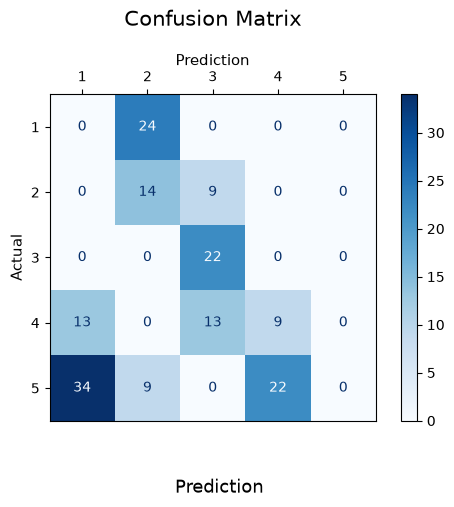

In [1]:
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('data/land_mines.csv')

"""
Q1:
There is 4 labels in this data set: voltage, height, soil, and mine_type.
Voltage is a float with a range between 0.0 and 1.0 
Height is a float with a range between 0.0 and 1.0
Soil is a float with a range between 0.0 and 1.0
Mine_type is a int with a range between 1 and 5
"""

# Q2
training_set = df[0:169]
testing_set = df[169:]

# Q3
# I selected k as 20 as if I had selected a small number like 3 or a large number like 50 I could have under or over fitted my data. so by picking 20 I stick to a middle ground where it was not too small nor was it too big
classification_X_raw = training_set[["voltage", "height"]]
classification_y = training_set["mine_type"]
classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=20).fit(
    classification_X_scaled, classification_y
)

# Q4
"""
I would say this model is not really accurate as it was only accurate for 3 and slightly accurate for both 2 and 4 however for 5 and 1 it was entirely inaccurate. So as the model gets further out from the center its accuracy severely degrades
"""
# Sources used: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
actual = testing_set["mine_type"].to_numpy()
predicted = classification_y.to_numpy()
classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(actual, predicted, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

# Q5 
# The advice I would give to someone on this model is if the data is in the middle of the list such as if we have a class of [1,2,3,4,5] the middle part 3 is extremely accurate 
# while as you get further out of the center such as 2 and 4 it is slightly accurate such that it may give incorrect data but there is a possibility that it can still be accurate
# while the outliers such as 1 and 5 should not be trusted at all as not a single data point that was predicted that was correct.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [2]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]